In [21]:
import numpy as np
import pyvista as pv
from scipy.spatial import KDTree
import sys
sys.path.append("..")
from error_func import error

case_name = "case2"
mesh_name = "coil_box"
solver1 = "moose"
solver2 = "ngsolve"

sol_moose = np.load(f"../../output/{case_name}/gauss/{case_name}_{solver1}.npy")
sol_ngsolve = np.load(f"../../output/{case_name}/gauss/{case_name}_{solver2}.npy")

print(sol_moose.shape)
print(sol_ngsolve.shape)

print(sol_moose.shape)
print(sol_ngsolve.shape)


(69629, 9)
(69629, 10)
(69629, 9)
(69629, 10)


In [22]:
print("Min and max X coord:")
print(np.min(sol_moose[:, 0:3]))
print(np.max(sol_moose[:, 0:3]))

print("Min and max Y coord:")
print(np.min(sol_moose[:, 0:3]))
print(np.max(sol_moose[:, 0:3]))

print("Min and max Z coord:")
print(np.min(sol_moose[:, 0:3]))
print(np.max(sol_moose[:, 0:3]))

print("")

print("Min and max X coord:")
print(np.min(sol_ngsolve[:, 0:3]))
print(np.max(sol_ngsolve[:, 0:3]))

print("Min and max Y coord:")
print(np.min(sol_ngsolve[:, 0:3]))
print(np.max(sol_ngsolve[:, 0:3]))

print("Min and max Z coord:")
print(np.min(sol_ngsolve[:, 0:3]))
print(np.max(sol_ngsolve[:, 0:3]))

Min and max X coord:
-0.099551605255125
0.09795298646876
Min and max Y coord:
-0.099551605255125
0.09795298646876
Min and max Z coord:
-0.099551605255125
0.09795298646876

Min and max X coord:
-0.099551605255125
0.09795298646876001
Min and max Y coord:
-0.099551605255125
0.09795298646876001
Min and max Z coord:
-0.099551605255125
0.09795298646876001


In [23]:
tree = KDTree(sol_moose[:, 0:3])
distances, indices = tree.query(sol_ngsolve[:, 0:3])

max_dist = np.max(distances)
print(f"Maximum alignment error (distance): {max_dist:.6e}")
if max_dist > 1e-4:
    print("Warning: Large distance detected. Are the geometries identical?")


sol_moose_reordered = sol_moose[indices, :]

np.save(f"../../output/{case_name}/gauss/{case_name}_{solver1}_reordered_to_{solver2}.npy", sol_moose_reordered)

Maximum alignment error (distance): 8.653332e-16


In [24]:
sol_moose = np.load(f"../../output/{case_name}/gauss/{case_name}_{solver1}_reordered_to_{solver2}.npy")
# elec_pot_moose = sol_moose[:, 9]
mag_flux_moose = sol_moose[:, 6:9]
mag_vec_moose = sol_moose[:, 3:6]

sol_ngsolve = np.load(f"../../output/{case_name}/gauss/{case_name}_{solver2}.npy")
# elec_pot_comsol = sol_comsol[:, 9]
mag_flux_ngsolve = sol_ngsolve[:, 6:9]
mag_vec_ngsolve = sol_ngsolve[:, 3:6]

# print(elec_pot_ngsolve.shape)
# print(elec_pot_comsol.shape)

print(mag_flux_moose.shape)
print(mag_flux_ngsolve.shape)
print(np.max(mag_flux_ngsolve))
print(np.max(mag_flux_moose))

print(np.min(mag_flux_ngsolve))
print(np.min(mag_flux_moose))

print("")

print(mag_vec_moose.shape)
print(mag_vec_ngsolve.shape)
print(np.max(mag_vec_ngsolve))
print(np.max(mag_vec_moose))

(69629, 3)
(69629, 3)
100353.78445948554
99859.359259539
-78813.85221451269
-78816.17155469

(69629, 3)
(69629, 3)
185707496329434.84
131610095865100.0


In [25]:
mesh = sol_moose[:, 0:3].copy()

In [26]:
print(f"Coordinate errors between {solver1} and {solver2}:")

mesh = error(sol=sol_moose[:, 0:3], sol_ref=sol_ngsolve[:, 0:3], 
             eps = 1e-12, mesh=mesh, tag="vector", save_tag=None)

# print(mesh.shape)

Coordinate errors between moose and ngsolve:

  * Max. absolute error in x direction  : 4.996e-16.
  * Avg. absolute error in x direction  : 1.147e-16.

  * Max. relative error in x direction : 4.995e-12 %.
  * Avg. relative error in x direction : 3.281e-13 %.

  * Max. absolute error in y direction  : 4.996e-16.
  * Avg. absolute error in y direction  : 1.028e-16.

  * Max. relative error in y direction : 4.992e-12 %.
  * Avg. relative error in y direction : 3.259e-13 %.

  * Max. absolute error in z direction  : 4.996e-16.
  * Avg. absolute error in z direction  : 7.845e-17.

  * Max. relative error in z direction : 4.996e-12 %.
  * Avg. relative error in z direction : 4.145e-13 %.


In [27]:
print(f"Magnetic flux density errors between {solver1} and {solver2}:")

mesh = error(sol=mag_flux_moose, sol_ref=mag_flux_ngsolve, 
             eps = 1e-6, mesh=mesh, tag="vector", save_tag=None, save_tag_array=True)

# print(mag_flux_moose[1100, :])
# print(mag_flux_ngsolve[1100, :])

# print(mesh.shape)

lim_x = (mesh[:, 3] > 10.0).sum()
lim_y = (mesh[:, 4] > 10.0).sum()
lim_z = (mesh[:, 5] > 10.0).sum()

print("")

print(f"Percent of values above 10% in x direction: {np.round(lim_x * 100 / mesh.shape[0], 2)}%")
print(f"Percent of values above 10% in y direction: {np.round(lim_y * 100 / mesh.shape[0], 2)}%")
print(f"Percent of values above 10% in z direction: {np.round(lim_z * 100 / mesh.shape[0], 2)}%")

B_x_err = mesh[:, 3]
B_y_err = mesh[:, 4]
B_z_err = mesh[:, 5]

B_x_err = np.extract(B_x_err<=10, B_x_err)
B_y_err = np.extract(B_y_err<=10, B_y_err)
B_z_err = np.extract(B_z_err<=10, B_z_err)

Magnetic flux density errors between moose and ngsolve:

  * Max. absolute error in x direction  : 1.056e+04.
  * Avg. absolute error in x direction  : 5.866e+01.

  * Max. relative error in x direction : 1.182e+04 %.
  * Avg. relative error in x direction : 2.087e+00 %.

  * Max. absolute error in y direction  : 5.266e+03.
  * Avg. absolute error in y direction  : 4.448e+01.

  * Max. relative error in y direction : 4.883e+04 %.
  * Avg. relative error in y direction : 5.691e+00 %.

  * Max. absolute error in z direction  : 1.357e+04.
  * Avg. absolute error in z direction  : 9.705e+01.

  * Max. relative error in z direction : 1.367e+04 %.
  * Avg. relative error in z direction : 2.053e+00 %.

Percent of values above 10% in x direction: 2.01%
Percent of values above 10% in y direction: 4.1%
Percent of values above 10% in z direction: 2.24%


/home/wiera/Documents/EM_simulation/scripts/case2/../error_func.py:62: RuntimeWarning: divide by zero encountered in divide
  rel_error_dir = np.where(denom > eps, num * 100 / denom, np.nan)
/home/wiera/Documents/EM_simulation/scripts/case2/../error_func.py:62: RuntimeWarning: invalid value encountered in divide
  rel_error_dir = np.where(denom > eps, num * 100 / denom, np.nan)


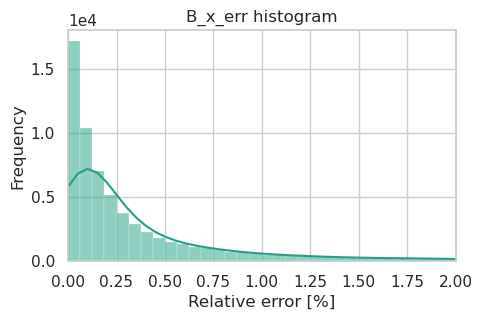

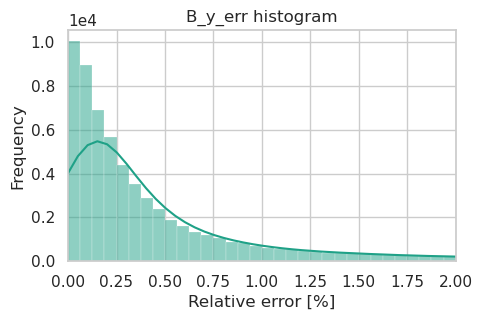

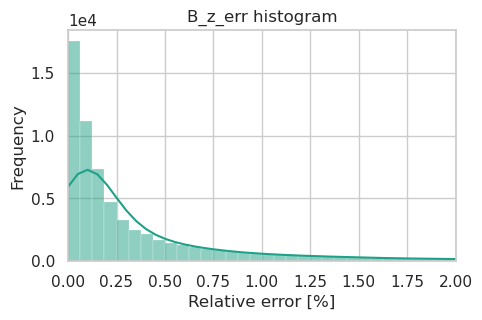

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid") 
palette = sns.color_palette("viridis") # You can use "rocket", "mako", or "flare"

fig, ax = plt.subplots(1, 1)
fig.set_figheight(3)
fig.set_figwidth(5)

sns.histplot(B_x_err, kde=True, color=palette[3], edgecolor="white", bins=160, ax=ax)

ax.set_title('B_x_err histogram', fontsize=12)
ax.set_xlabel('Relative error [%]', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xlim(0.0, 2.0)

plt.ticklabel_format(axis='both', style='sci', scilimits=(-2,2))

plt.show()


fig, ax = plt.subplots(1, 1)
fig.set_figheight(3)
fig.set_figwidth(5)

sns.histplot(B_y_err, kde=True, color=palette[3], edgecolor="white", bins=160, ax=ax)

ax.set_title('B_y_err histogram', fontsize=12)
ax.set_xlabel('Relative error [%]', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xlim(0.0, 2.0)

plt.ticklabel_format(axis='both', style='sci', scilimits=(-2,2))

plt.show()


fig, ax = plt.subplots(1, 1)
fig.set_figheight(3)
fig.set_figwidth(5)

sns.histplot(B_z_err, kde=True, color=palette[3], edgecolor="white", bins=160, ax=ax)

ax.set_title('B_z_err histogram', fontsize=12)
ax.set_xlabel('Relative error [%]', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

ax.set_xlim(0.0, 2.0)

plt.ticklabel_format(axis='both', style='sci', scilimits=(-2,2))

plt.show()

In [29]:
print(f"Magnetic vector potential errors between {solver1} and {solver2}:")

mesh = error(sol=mag_vec_moose, sol_ref=mag_vec_ngsolve, 
             eps = 1e-6, mesh=mesh, tag="vector", save_tag=None)

Magnetic vector potential errors between moose and ngsolve:

  * Max. absolute error in x direction  : 7.304e+13.
  * Avg. absolute error in x direction  : 6.061e+11.

  * Max. relative error in x direction : 1.098e+06 %.
  * Avg. relative error in x direction : 1.170e+02 %.

  * Max. absolute error in y direction  : 8.484e+13.
  * Avg. absolute error in y direction  : 6.564e+11.

  * Max. relative error in y direction : 5.288e+05 %.
  * Avg. relative error in y direction : 9.288e+01 %.

  * Max. absolute error in z direction  : 8.671e+13.
  * Avg. absolute error in z direction  : 5.359e+11.

  * Max. relative error in z direction : 6.680e+05 %.
  * Avg. relative error in z direction : 1.415e+02 %.


In [30]:
np.save(f"../../output/{case_name}/gauss/{case_name}_error_ngsolve_moose.npy", mesh)
np.savetxt(f"../../output/{case_name}/gauss/{case_name}_error_ngsolve_moose.txt", mesh, delimiter=',', header='x,y,z,B_x_err,B_y_err,B_z_err')